# Experiment 19b - V3 Agreement Visualizations & Case Studies

**Inputs:** Human A, Human B, and LLM V3 annotations for 10 struggling students.

**Outputs:** 3 figures, 1 case-study markdown file, and a three-way comparison CSV.

## Setup

Imports, constants, project paths, and plotting defaults.

In [1]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

matplotlib.rcParams["figure.dpi"] = 150
matplotlib.rcParams["savefig.dpi"] = 300
matplotlib.rcParams["font.size"] = 11

ROOT = Path("/mnt/d/Projects/kintsugi").resolve()
VIZ_DIR = ROOT / "results" / "human_validation" / "exp19_visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

STUDENT_IDS = [10155, 9948, 14189, 14352, 14362, 14363, 14374, 14414, 14474, 14499]

KC_COLUMNS = [
    "If/Else", "NestedIf", "While", "For", "NestedFor",
    "Math+-*/", "Math%", "LogicAndNotOr", "LogicCompareNum", "LogicBoolean",
    "StringFormat", "StringConcat", "StringIndex", "StringLen",
    "StringEqual", "CharEqual", "ArrayIndex", "DefFunction",
]

HUMAN_A_NAME = "Pranay Ghuge"
HUMAN_B_NAME = "Arundhati Das"

PATHS = {
    "human_dir": ROOT / "dataset" / "Rater_KC_Tags" / "Rated_KC_V3",
    "llm_dir": ROOT / "results" / "human_validation" / "llm_v3_10students",
    "code_dir": ROOT / "scripts" / "annotation_tool" / "annotation_inputs",
    "problem_prompts": ROOT / "dataset" / "CodeWorkout" / "Problem_Prompts" / "problem_prompts.csv",
    "metrics_dir": ROOT / "results" / "human_validation" / "v3_prompt_eval_results",
    "output_dir": VIZ_DIR,
    "comparison_csv": ROOT / "results" / "human_validation" / "exp19_three_way_comparison.csv",
}

print(f"Root: {ROOT}")
print(f"Output dir: {VIZ_DIR}")

Root: /mnt/d/Projects/kintsugi
Output dir: /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations


## Helper Functions

These functions validate the current file layout, load annotation JSON safely, and build the unified three-way table.

In [2]:
def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def load_annotation_file(path: Path) -> dict[str, set[str]]:
    """Load annotation JSON as {problem_id: set(gap KCs)}."""
    data = load_json(path)
    annotations = data.get("annotations")
    if not isinstance(annotations, dict):
        raise ValueError(f"{path} does not contain an annotations object")

    known_kcs = set(KC_COLUMNS)
    result: dict[str, set[str]] = {}
    unknown: set[str] = set()
    for problem_id, entry in annotations.items():
        if not isinstance(entry, dict):
            raise ValueError(f"{path} problem {problem_id} annotation is not an object")
        gaps = entry.get("gaps", [])
        if gaps is None:
            gaps = []
        if not isinstance(gaps, list):
            raise ValueError(f"{path} problem {problem_id} gaps is not a list")
        gap_set = {str(gap) for gap in gaps}
        unknown.update(gap_set - known_kcs)
        result[str(problem_id)] = gap_set

    if unknown:
        raise ValueError(f"{path} contains unknown KC labels: {sorted(unknown)}")
    return result


def annotation_sort_key(path: Path) -> tuple[int, str]:
    """Sort annotation exports by numeric timestamp suffix when present."""
    match = re.search(r"_(\d+)\.json$", path.name)
    timestamp = int(match.group(1)) if match else -1
    return timestamp, path.name


def find_annotation_file(directory: Path, rater: str, student_id: int) -> Path:
    pattern = f"kc_annotations_{rater}_{student_id}_*.json"
    matches = sorted(directory.glob(pattern), key=annotation_sort_key)
    if not matches:
        raise FileNotFoundError(f"No annotation file matches {directory / pattern}")
    return matches[-1]


def required_kcs_for_problem(problem_row: pd.Series) -> list[str]:
    required: list[str] = []
    for kc in KC_COLUMNS:
        value = problem_row.get(kc)
        if pd.notna(value) and int(value) == 1:
            required.append(kc)
    return required


def validate_inputs(paths: dict[str, Path]) -> None:
    required_paths = [
        paths["human_dir"], paths["llm_dir"], paths["code_dir"],
        paths["problem_prompts"], paths["metrics_dir"],
    ]
    for path in required_paths:
        if not path.exists():
            raise FileNotFoundError(f"Required path does not exist: {path}")

    metric_files = [
        "overall_metrics.csv", "per_kc_pair_metrics.csv", "per_student_metrics.csv",
        "ceiling_metrics.csv", "per_kc_ceiling_metrics.csv", "v3_prompt_eval_summary.json",
    ]
    missing_metrics = [name for name in metric_files if not (paths["metrics_dir"] / name).exists()]
    if missing_metrics:
        raise FileNotFoundError(f"Missing precomputed metric files: {missing_metrics}")

    for student_id in STUDENT_IDS:
        find_annotation_file(paths["human_dir"], HUMAN_A_NAME, student_id)
        find_annotation_file(paths["human_dir"], HUMAN_B_NAME, student_id)
        llm_file = paths["llm_dir"] / f"llm_v3_annotations_{student_id}.json"
        code_file = paths["code_dir"] / f"student_{student_id}.json"
        if not llm_file.exists():
            raise FileNotFoundError(f"Missing LLM annotations: {llm_file}")
        if not code_file.exists():
            raise FileNotFoundError(f"Missing student code input: {code_file}")


def build_three_way_dataframe(paths: dict[str, Path]) -> pd.DataFrame:
    problem_prompts = pd.read_csv(paths["problem_prompts"])
    required_problem_columns = {"AssignmentID", "ProblemID", "Requirement", *KC_COLUMNS}
    missing_columns = required_problem_columns - set(problem_prompts.columns)
    if missing_columns:
        raise ValueError(f"Problem prompt CSV is missing columns: {sorted(missing_columns)}")

    problem_prompts_by_id = problem_prompts.set_index("ProblemID", drop=False)
    rows: list[dict[str, Any]] = []

    for student_id in STUDENT_IDS:
        human_a_file = find_annotation_file(paths["human_dir"], HUMAN_A_NAME, student_id)
        human_b_file = find_annotation_file(paths["human_dir"], HUMAN_B_NAME, student_id)
        llm_file = paths["llm_dir"] / f"llm_v3_annotations_{student_id}.json"
        code_file = paths["code_dir"] / f"student_{student_id}.json"

        human_a = load_annotation_file(human_a_file)
        human_b = load_annotation_file(human_b_file)
        llm = load_annotation_file(llm_file)

        code_data = load_json(code_file)
        submissions = code_data.get("submissions")
        if not isinstance(submissions, dict):
            raise ValueError(f"{code_file} does not contain a submissions object")

        common_problem_ids = set(human_a) & set(human_b) & set(llm)
        if not common_problem_ids:
            raise ValueError(f"No common problem IDs across raters for student {student_id}")

        missing_by_source = {
            "Human A": sorted((set(human_b) | set(llm)) - set(human_a), key=int),
            "Human B": sorted((set(human_a) | set(llm)) - set(human_b), key=int),
            "LLM": sorted((set(human_a) | set(human_b)) - set(llm), key=int),
        }
        for source, missing in missing_by_source.items():
            if missing:
                print(f"WARNING: Student {student_id} {source} missing problem IDs: {missing}")

        for problem_id_str in sorted(common_problem_ids, key=int):
            problem_id = int(problem_id_str)
            if problem_id not in problem_prompts_by_id.index:
                raise ValueError(f"ProblemID {problem_id} is missing from problem_prompts.csv")

            problem_row = problem_prompts_by_id.loc[problem_id]
            submission = submissions.get(problem_id_str, {})
            if not isinstance(submission, dict):
                submission = {}

            ha_gaps = human_a[problem_id_str]
            hb_gaps = human_b[problem_id_str]
            llm_gaps = llm[problem_id_str]
            required_kcs = required_kcs_for_problem(problem_row)

            row: dict[str, Any] = {
                "StudentID": student_id,
                "ProblemID": problem_id,
                "AssignmentID": int(problem_row["AssignmentID"]),
                "Score": submission.get("score", np.nan),
                "Requirement": problem_row["Requirement"],
                "Code": submission.get("code", ""),
                "RequiredKCs": json.dumps(required_kcs),
                "HA_gaps": json.dumps(sorted(ha_gaps)),
                "HB_gaps": json.dumps(sorted(hb_gaps)),
                "LLM_gaps": json.dumps(sorted(llm_gaps)),
            }
            for kc in KC_COLUMNS:
                row[f"HA_{kc}"] = int(kc in ha_gaps)
                row[f"HB_{kc}"] = int(kc in hb_gaps)
                row[f"LLM_{kc}"] = int(kc in llm_gaps)
            rows.append(row)

    df = pd.DataFrame(rows)
    expected_students = set(STUDENT_IDS)
    actual_students = set(df["StudentID"].unique())
    if actual_students != expected_students:
        raise ValueError(f"Expected students {sorted(expected_students)}, got {sorted(actual_students)}")
    return df

## Load Unified Three-Way Comparison Table

Each row is a `(StudentID, ProblemID)` pair, with binary Human A, Human B, and LLM V3 columns for every KC.

In [3]:
validate_inputs(PATHS)

df = build_three_way_dataframe(PATHS)
df.to_csv(PATHS["comparison_csv"], index=False)

print(f"Loaded {len(df)} problem rows across {df['StudentID'].nunique()} students")
print(f"Students: {sorted(int(student_id) for student_id in df['StudentID'].unique())}")
print(f"Saved: {PATHS['comparison_csv']}")

Loaded 372 problem rows across 10 students
Students: [9948, 10155, 14189, 14352, 14362, 14363, 14374, 14414, 14474, 14499]
Saved: /mnt/d/Projects/kintsugi/results/human_validation/exp19_three_way_comparison.csv


## Visualization 1: Per-KC F1 Grouped Bar Chart

Three bars per KC: Human A vs Human B, Human A vs LLM V3, and Human B vs LLM V3. KCs are sorted by human-ceiling F1.

In [4]:
def compute_binary_f1(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    if tp == 0:
        return 0.0
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return 2 * precision * recall / (precision + recall)


kc_f1_data = []
for kc in KC_COLUMNS:
    ha = df[f"HA_{kc}"].to_numpy()
    hb = df[f"HB_{kc}"].to_numpy()
    llm = df[f"LLM_{kc}"].to_numpy()
    f1_ha_llm = compute_binary_f1(ha, llm)
    f1_hb_llm = compute_binary_f1(hb, llm)
    kc_f1_data.append({
        "KC": kc,
        "H-H F1": compute_binary_f1(ha, hb),
        "HA-LLM F1": f1_ha_llm,
        "HB-LLM F1": f1_hb_llm,
        "LLM Avg F1": (f1_ha_llm + f1_hb_llm) / 2,
        "HA_count": int(ha.sum()),
        "HB_count": int(hb.sum()),
        "LLM_count": int(llm.sum()),
    })

kc_f1_df = pd.DataFrame(kc_f1_data).sort_values("H-H F1", ascending=False)
print(kc_f1_df[["KC", "H-H F1", "HA-LLM F1", "HB-LLM F1", "LLM Avg F1"]].to_string(index=False))

             KC   H-H F1  HA-LLM F1  HB-LLM F1  LLM Avg F1
   StringFormat 0.788732   0.360000   0.326531    0.343265
LogicCompareNum 0.750000   0.488550   0.571429    0.529989
    StringIndex 0.655172   0.676923   0.679245    0.678084
    StringEqual 0.608696   0.434783   0.538462    0.486622
  LogicAndNotOr 0.600000   0.370370   0.470588    0.420479
      CharEqual 0.571429   0.181818   0.285714    0.233766
       Math+-*/ 0.510638   0.500000   0.486486    0.493243
   StringConcat 0.500000   0.625000   0.500000    0.562500
     ArrayIndex 0.490566   0.709677   0.536585    0.623131
   LogicBoolean 0.387097   0.580645   0.466667    0.523656
            For 0.296296   0.444444   0.076923    0.260684
          Math% 0.200000   0.444444   0.666667    0.555556
      StringLen 0.200000   0.424242   0.370370    0.397306
        If/Else 0.173913   0.172414   0.139535    0.155974
       NestedIf 0.000000   0.000000   0.000000    0.000000
      NestedFor 0.000000   0.000000   0.000000    0.0000

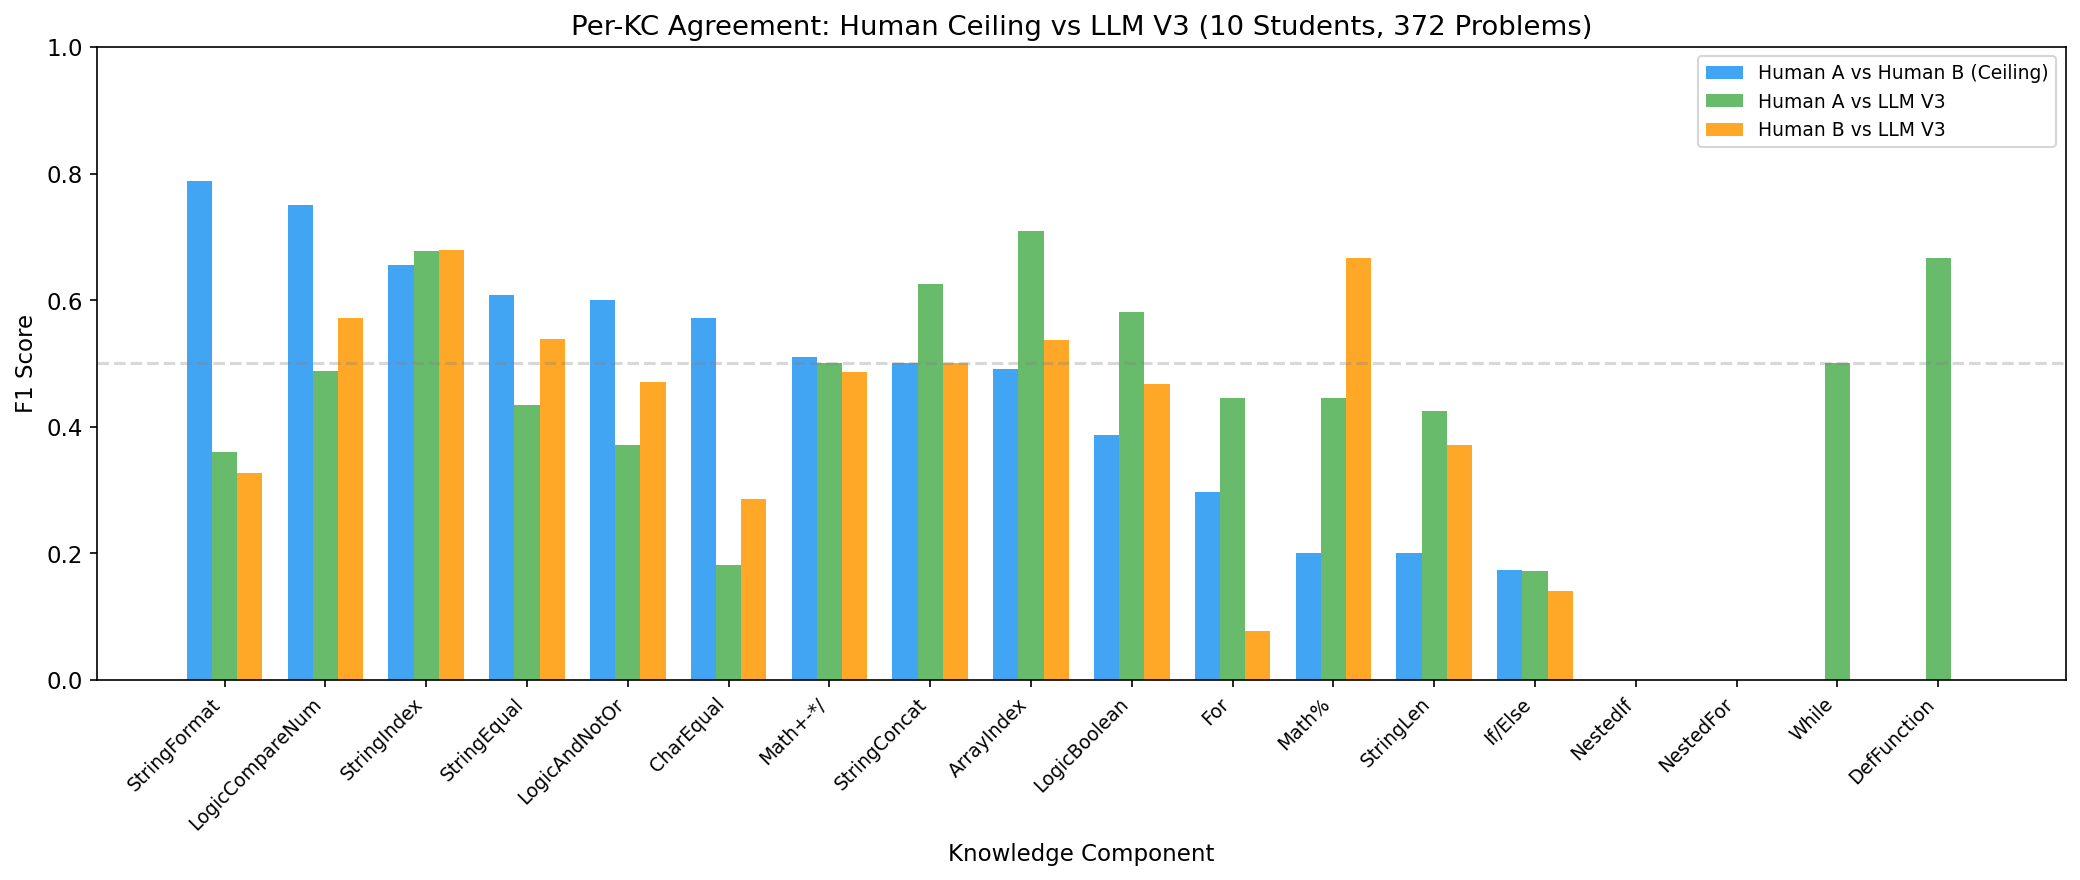

Saved: /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/exp19_per_kc_f1_grouped_bars.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(kc_f1_df))
width = 0.25

ax.bar(x - width, kc_f1_df["H-H F1"], width, label="Human A vs Human B (Ceiling)", color="#2196F3", alpha=0.85)
ax.bar(x, kc_f1_df["HA-LLM F1"], width, label="Human A vs LLM V3", color="#4CAF50", alpha=0.85)
ax.bar(x + width, kc_f1_df["HB-LLM F1"], width, label="Human B vs LLM V3", color="#FF9800", alpha=0.85)

ax.set_xlabel("Knowledge Component")
ax.set_ylabel("F1 Score")
ax.set_title("Per-KC Agreement: Human Ceiling vs LLM V3 (10 Students, 372 Problems)")
ax.set_xticks(x)
ax.set_xticklabels(kc_f1_df["KC"], rotation=45, ha="right", fontsize=9)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
save_path = VIZ_DIR / "exp19_per_kc_f1_grouped_bars.png"
plt.savefig(save_path)
plt.show()
print(f"Saved: {save_path}")

## Visualization 2: Confusion Direction Per KC

For each KC, this shows whether LLM V3 over-tags or under-tags relative to human consensus.

In [6]:
confusion_data = []

for kc in KC_COLUMNS:
    ha = df[f"HA_{kc}"].to_numpy()
    hb = df[f"HB_{kc}"].to_numpy()
    llm = df[f"LLM_{kc}"].to_numpy()

    consensus_gap = (ha == 1) & (hb == 1)
    consensus_no_gap = (ha == 0) & (hb == 0)
    humans_disagree = ha != hb

    tp = int(np.sum(consensus_gap & (llm == 1)))
    fp = int(np.sum(consensus_no_gap & (llm == 1)))
    fn = int(np.sum(consensus_gap & (llm == 0)))
    tn = int(np.sum(consensus_no_gap & (llm == 0)))

    confusion_data.append({
        "KC": kc,
        "TP": tp,
        "FP_overtag": fp,
        "FN_undertag": fn,
        "TN": tn,
        "Net_Bias": fp - fn,
        "Human_Disagree": int(np.sum(humans_disagree)),
        "LLM_sides_A": int(np.sum(humans_disagree & (llm == ha))),
        "LLM_sides_B": int(np.sum(humans_disagree & (llm == hb))),
    })

conf_df = pd.DataFrame(confusion_data).sort_values("Net_Bias")
print("Confusion Direction (negative = under-tags, positive = over-tags):")
print(conf_df[["KC", "TP", "FP_overtag", "FN_undertag", "Net_Bias", "Human_Disagree", "LLM_sides_A", "LLM_sides_B"]].to_string(index=False))

Confusion Direction (negative = under-tags, positive = over-tags):
             KC  TP  FP_overtag  FN_undertag  Net_Bias  Human_Disagree  LLM_sides_A  LLM_sides_B
LogicCompareNum  28           7           32       -25              40           12           28
  LogicAndNotOr  14           6           25       -19              52           32           20
   StringFormat   6           3           22       -19              15            8            7
       Math+-*/   6           2            6        -4              23           11           12
     ArrayIndex   9           1            4        -3              27           14           13
          Math%   1           0            0         0               8            3            5
      NestedFor   0           0            0         0               3            2            1
   StringConcat   7           3            3         0              20           14            6
    StringIndex  15           5            4         1      

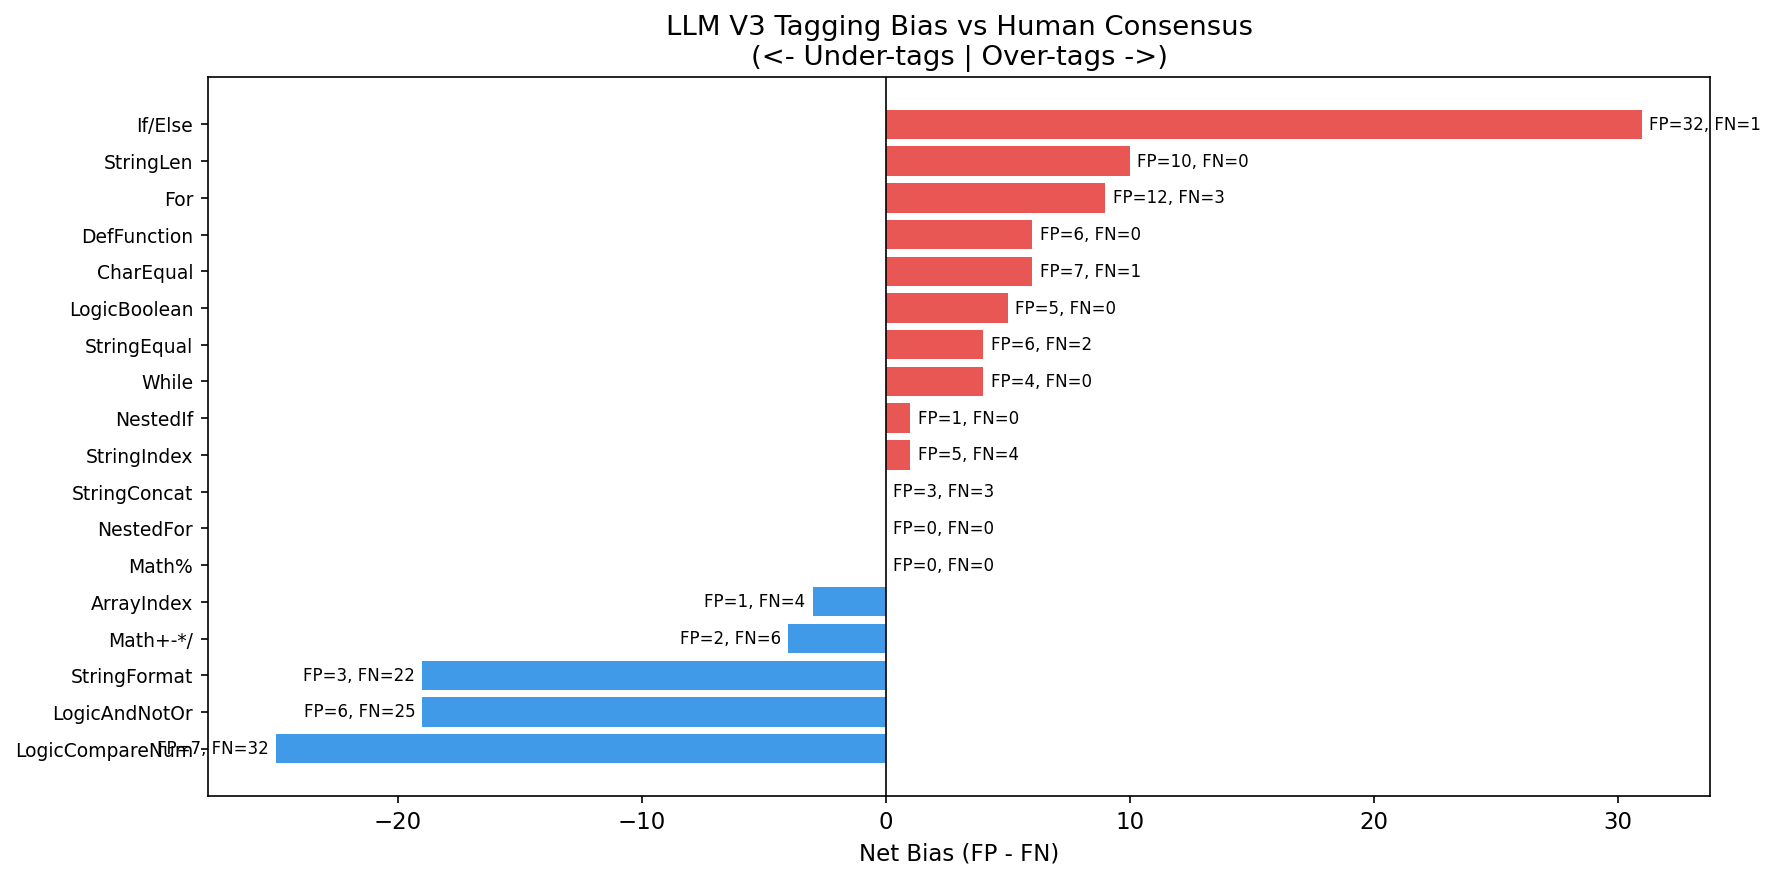

Saved: /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/exp19_confusion_direction_per_kc.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

net_bias = conf_df["Net_Bias"].to_numpy()
colors = ["#E53935" if bias > 0 else "#1E88E5" for bias in net_bias]
y_pos = np.arange(len(conf_df))

ax.barh(y_pos, net_bias, color=colors, alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(conf_df["KC"], fontsize=9)
ax.set_xlabel("Net Bias (FP - FN)")
ax.set_title("LLM V3 Tagging Bias vs Human Consensus\n(<- Under-tags | Over-tags ->)")
ax.axvline(x=0, color="black", linewidth=0.8)

for i, value in enumerate(net_bias):
    fp = int(conf_df.iloc[i]["FP_overtag"])
    fn = int(conf_df.iloc[i]["FN_undertag"])
    ax.text(
        value + (0.3 if value >= 0 else -0.3),
        i,
        f"FP={fp}, FN={fn}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=8,
    )

plt.tight_layout()
save_path = VIZ_DIR / "exp19_confusion_direction_per_kc.png"
plt.savefig(save_path)
plt.show()
print(f"Saved: {save_path}")

## Visualization 3: Agreement Triangle

Each `(student, problem, KC)` decision is classified by which raters agree with each other.

In [8]:
categories = {
    "All Agree Gap": 0,
    "All Agree No Gap": 0,
    "H-H Agree, LLM Diverges": 0,
    "HA+LLM Agree, HB Diverges": 0,
    "HB+LLM Agree, HA Diverges": 0,
    "All Three Disagree": 0,
}

kc_categories = {kc: dict(categories) for kc in KC_COLUMNS}

for kc in KC_COLUMNS:
    ha = df[f"HA_{kc}"].to_numpy()
    hb = df[f"HB_{kc}"].to_numpy()
    llm = df[f"LLM_{kc}"].to_numpy()

    for a, b, l in zip(ha, hb, llm):
        if a == b == l:
            key = "All Agree Gap" if a == 1 else "All Agree No Gap"
        elif a == b and a != l:
            key = "H-H Agree, LLM Diverges"
        elif a == l and a != b:
            key = "HA+LLM Agree, HB Diverges"
        elif b == l and b != a:
            key = "HB+LLM Agree, HA Diverges"
        else:
            key = "All Three Disagree"
        categories[key] += 1
        kc_categories[kc][key] += 1

total = sum(categories.values())
print(f"Total KC decisions: {total} (expected: {len(df)} x {len(KC_COLUMNS)} = {len(df) * len(KC_COLUMNS)})")
print()
print(f"{'Category':<35} {'Count':>6} {'%':>7}")
print("-" * 50)
for category, count in categories.items():
    pct = 100 * count / total
    print(f"{category:<35} {count:>6} {pct:>6.1f}%")

Total KC decisions: 6696 (expected: 372 x 18 = 6696)

Category                             Count       %
--------------------------------------------------
All Agree Gap                          102    1.5%
All Agree No Gap                      6072   90.7%
H-H Agree, LLM Diverges                213    3.2%
HA+LLM Agree, HB Diverges              153    2.3%
HB+LLM Agree, HA Diverges              156    2.3%
All Three Disagree                       0    0.0%


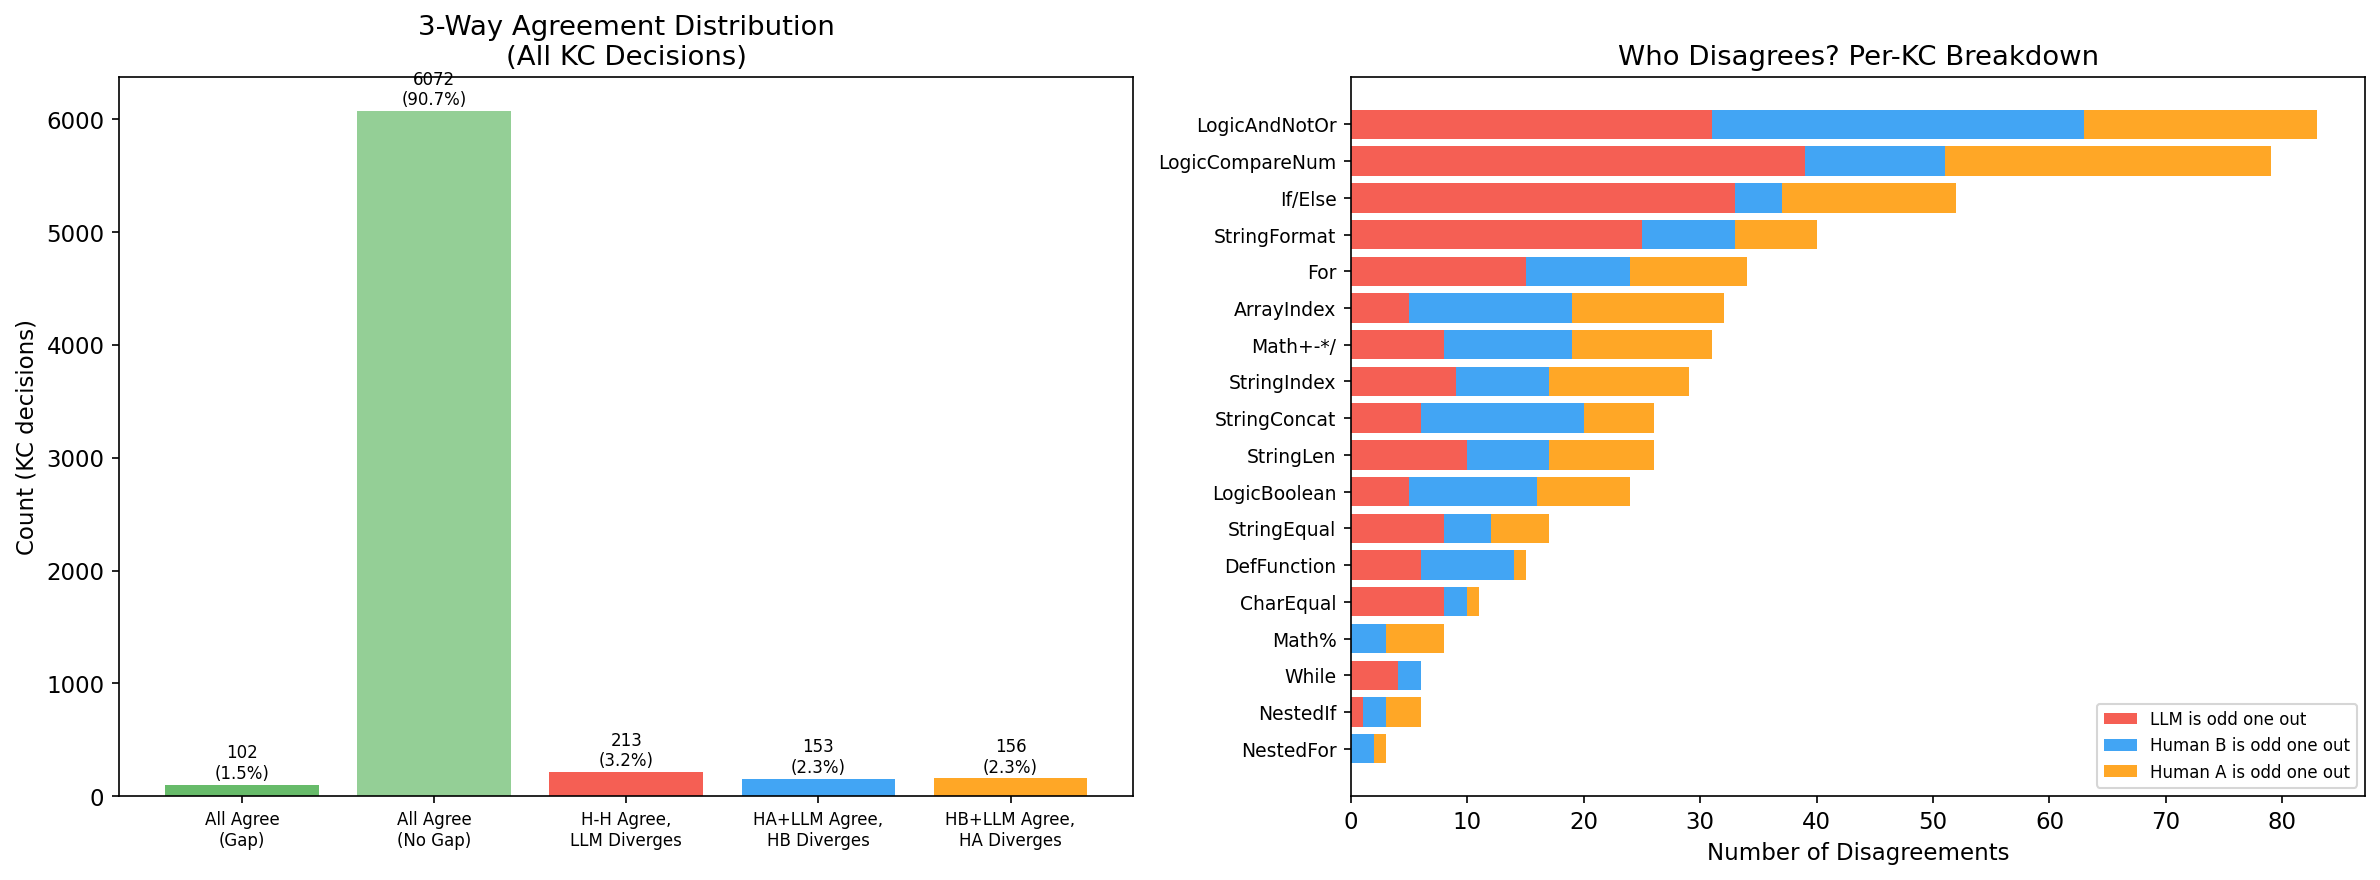

Saved: /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/exp19_agreement_triangle.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cat_labels = [
    "All Agree\n(Gap)",
    "All Agree\n(No Gap)",
    "H-H Agree,\nLLM Diverges",
    "HA+LLM Agree,\nHB Diverges",
    "HB+LLM Agree,\nHA Diverges",
]
cat_values = [
    categories["All Agree Gap"],
    categories["All Agree No Gap"],
    categories["H-H Agree, LLM Diverges"],
    categories["HA+LLM Agree, HB Diverges"],
    categories["HB+LLM Agree, HA Diverges"],
]
cat_colors = ["#4CAF50", "#81C784", "#F44336", "#2196F3", "#FF9800"]

bars = ax1.bar(range(len(cat_labels)), cat_values, color=cat_colors, alpha=0.85)
ax1.set_xticks(range(len(cat_labels)))
ax1.set_xticklabels(cat_labels, fontsize=8)
ax1.set_ylabel("Count (KC decisions)")
ax1.set_title("3-Way Agreement Distribution\n(All KC Decisions)")

for bar, value in zip(bars, cat_values):
    pct = 100 * value / total
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, f"{value}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8)

# Right panel: per-KC breakdown of disagreement only.
disagree_rows = []
for kc in KC_COLUMNS:
    counts = kc_categories[kc]
    total_disagree = counts["H-H Agree, LLM Diverges"] + counts["HA+LLM Agree, HB Diverges"] + counts["HB+LLM Agree, HA Diverges"]
    if total_disagree > 0:
        disagree_rows.append({
            "KC": kc,
            "LLM Diverges": counts["H-H Agree, LLM Diverges"],
            "HB Diverges": counts["HA+LLM Agree, HB Diverges"],
            "HA Diverges": counts["HB+LLM Agree, HA Diverges"],
            "Total Disagree": total_disagree,
        })

dkc_df = pd.DataFrame(disagree_rows).sort_values("Total Disagree", ascending=True)
y_pos = np.arange(len(dkc_df))
ax2.barh(y_pos, dkc_df["LLM Diverges"], color="#F44336", alpha=0.85, label="LLM is odd one out")
ax2.barh(y_pos, dkc_df["HB Diverges"], left=dkc_df["LLM Diverges"], color="#2196F3", alpha=0.85, label="Human B is odd one out")
ax2.barh(y_pos, dkc_df["HA Diverges"], left=dkc_df["LLM Diverges"].to_numpy() + dkc_df["HB Diverges"].to_numpy(), color="#FF9800", alpha=0.85, label="Human A is odd one out")

ax2.set_yticks(y_pos)
ax2.set_yticklabels(dkc_df["KC"], fontsize=9)
ax2.set_xlabel("Number of Disagreements")
ax2.set_title("Who Disagrees? Per-KC Breakdown")
ax2.legend(loc="lower right", fontsize=8)

plt.tight_layout()
save_path = VIZ_DIR / "exp19_agreement_triangle.png"
plt.savefig(save_path)
plt.show()
print(f"Saved: {save_path}")

## Case Studies

Find representative examples for: shared agreement, human consensus vs LLM divergence, LLM within human variance, and LLM-only tags.

In [10]:
case_candidates = []

for _, row in df.iterrows():
    ha_gaps = set(json.loads(row["HA_gaps"]))
    hb_gaps = set(json.loads(row["HB_gaps"]))
    llm_gaps = set(json.loads(row["LLM_gaps"]))
    all_gaps = ha_gaps | hb_gaps | llm_gaps
    if not all_gaps:
        continue

    llm_only = llm_gaps - ha_gaps - hb_gaps
    shared_by_all = ha_gaps & hb_gaps & llm_gaps
    required = set(json.loads(row["RequiredKCs"]))

    case_candidates.append({
        "StudentID": int(row["StudentID"]),
        "ProblemID": int(row["ProblemID"]),
        "Score": row["Score"],
        "HA_gaps": sorted(ha_gaps),
        "HB_gaps": sorted(hb_gaps),
        "LLM_gaps": sorted(llm_gaps),
        "RequiredKCs": sorted(required),
        "Code": row["Code"],
        "Requirement": row["Requirement"],
        "is_case_a_exact": ha_gaps == hb_gaps == llm_gaps and len(all_gaps) > 0,
        "is_case_a_shared": len(shared_by_all) > 0,
        "is_case_b": ha_gaps == hb_gaps and llm_gaps != ha_gaps and len(ha_gaps) > 0,
        "is_case_c": (llm_gaps == ha_gaps and llm_gaps != hb_gaps) or (llm_gaps == hb_gaps and llm_gaps != ha_gaps),
        "is_case_d": len(llm_only) > 0,
        "n_gaps": len(all_gaps),
        "shared_by_all": sorted(shared_by_all),
        "llm_only_tags": sorted(llm_only),
        "llm_only_in_required": sorted(llm_only & required),
    })

cand_df = pd.DataFrame(case_candidates)

print(f"Total problems with at least one gap: {len(cand_df)}")
print(f"Case A exact full-set agreement: {cand_df['is_case_a_exact'].sum()}")
print(f"Case A shared-gap fallback: {cand_df['is_case_a_shared'].sum()}")
print(f"Case B (H-H agree, LLM differs): {cand_df['is_case_b'].sum()}")
print(f"Case C (LLM matches one human): {cand_df['is_case_c'].sum()}")
print(f"Case D (LLM tags unique KC): {cand_df['is_case_d'].sum()}")

Total problems with at least one gap: 135
Case A exact full-set agreement: 0
Case A shared-gap fallback: 70
Case B (H-H agree, LLM differs): 10
Case C (LLM matches one human): 13
Case D (LLM tags unique KC): 66


In [11]:
def pick_best(subset: pd.DataFrame, prefer_mid_score: bool = True) -> pd.Series | None:
    if subset.empty:
        return None

    selected_subset = subset
    good_gap_count = selected_subset[(selected_subset["n_gaps"] >= 2) & (selected_subset["n_gaps"] <= 5)]
    if not good_gap_count.empty:
        selected_subset = good_gap_count

    if prefer_mid_score:
        mid_score = selected_subset[(selected_subset["Score"] > 0.0) & (selected_subset["Score"] < 1.0)]
        if not mid_score.empty:
            selected_subset = mid_score

    return selected_subset.sort_values(["n_gaps", "StudentID", "ProblemID"], ascending=[False, True, True]).iloc[0]


selected = {}

case_a_exact = cand_df[cand_df["is_case_a_exact"]]
case_a_shared = cand_df[cand_df["is_case_a_shared"]]
case_a = pick_best(case_a_exact if not case_a_exact.empty else case_a_shared)
if case_a is not None:
    selected["A"] = case_a

case_b = pick_best(cand_df[cand_df["is_case_b"]])
if case_b is not None:
    selected["B"] = case_b

case_c = pick_best(cand_df[cand_df["is_case_c"]])
if case_c is not None:
    selected["C"] = case_c

case_d_pool = cand_df[cand_df["is_case_d"]]
case_d_with_required = case_d_pool[case_d_pool["llm_only_in_required"].apply(len) > 0]
case_d = pick_best(case_d_with_required if not case_d_with_required.empty else case_d_pool)
if case_d is not None:
    selected["D"] = case_d

print("=" * 60)
print("SELECTED CASE STUDIES")
print("=" * 60)
for label in ["A", "B", "C", "D"]:
    if label in selected:
        row = selected[label]
        print(f"Case {label}: Student {row['StudentID']}, Problem {row['ProblemID']} | score={row['Score']}")
        print(f"  HA: {row['HA_gaps']}")
        print(f"  HB: {row['HB_gaps']}")
        print(f"  LLM: {row['LLM_gaps']}")
    else:
        print(f"Case {label}: no candidate found")

SELECTED CASE STUDIES
Case A: Student 9948, Problem 22 | score=0.36
  HA: ['DefFunction', 'If/Else', 'LogicAndNotOr', 'NestedIf']
  HB: ['LogicAndNotOr', 'LogicCompareNum']
  LLM: ['DefFunction', 'LogicAndNotOr', 'LogicCompareNum']
Case B: Student 10155, Problem 24 | score=0.590909
  HA: ['LogicAndNotOr', 'LogicCompareNum', 'Math+-*/']
  HB: ['LogicAndNotOr', 'LogicCompareNum', 'Math+-*/']
  LLM: ['If/Else', 'LogicCompareNum']
Case C: Student 14189, Problem 24 | score=0.8636360000000001
  HA: ['If/Else', 'LogicCompareNum', 'Math+-*/']
  HB: ['LogicAndNotOr', 'LogicCompareNum']
  LLM: ['LogicAndNotOr', 'LogicCompareNum']
Case D: Student 10155, Problem 37 | score=0.666667
  HA: ['LogicCompareNum', 'StringIndex', 'StringLen']
  HB: []
  LLM: ['LogicAndNotOr', 'StringEqual']


In [12]:
case_titles = {
    "A": "All Three Raters Share a Gap - V3 Works",
    "B": "Humans Agree, LLM Diverges - V3 Fails",
    "C": "LLM Agrees With One Human - V3 Within Human Variance",
    "D": "LLM Finds Unique Insight - V3 Adds Value",
}

md_lines = ["# Case Studies: V3 LLM vs Human Annotation Agreement\n\n"]
md_lines.append("**Dataset:** 10 struggling students, 372 problems, 6,696 binary KC decisions\n\n")

for label in ["A", "B", "C", "D"]:
    if label not in selected:
        continue

    row = selected[label]
    code_text = str(row["Code"]).replace("\r\n", "\n").replace("\r", "\n").strip()
    required_kcs = ", ".join(row["RequiredKCs"]) if row["RequiredKCs"] else "(none)"

    md_lines.append(f"## Case {label}: {case_titles[label]}\n\n")
    md_lines.append(f"**Student {row['StudentID']}, Problem {row['ProblemID']}** | Score: {row['Score']}\n\n")
    md_lines.append(f"**Required KCs:** {required_kcs}\n\n")
    md_lines.append(f"**Problem:** {row['Requirement']}\n\n")
    md_lines.append(f"**Student Code:**\n\n```java\n{code_text}\n```\n\n")
    md_lines.append("| Rater | Tagged Gaps |\n|---|---|\n")
    md_lines.append(f"| Human A ({HUMAN_A_NAME.split()[0]}) | {', '.join(row['HA_gaps']) if row['HA_gaps'] else '(none)'} |\n")
    md_lines.append(f"| Human B ({HUMAN_B_NAME.split()[0]}) | {', '.join(row['HB_gaps']) if row['HB_gaps'] else '(none)'} |\n")
    md_lines.append(f"| LLM V3 | {', '.join(row['LLM_gaps']) if row['LLM_gaps'] else '(none)'} |\n\n")

    if label == "A":
        md_lines.append(f"**Shared by all three:** {', '.join(row['shared_by_all']) if row['shared_by_all'] else '(none)'}\n\n")
    if label == "D":
        md_lines.append(f"**LLM-only tags:** {', '.join(row['llm_only_tags']) if row['llm_only_tags'] else '(none)'}\n\n")

    md_lines.append("**Analysis:** [TODO: Write narrative for thesis]\n\n---\n\n")

md_path = VIZ_DIR / "exp19_case_studies.md"
md_path.write_text("".join(md_lines), encoding="utf-8")
print(f"Saved: {md_path}")


Saved: /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/exp19_case_studies.md


## Summary Statistics

Final dataset, agreement, and output-path summary.

In [13]:
ceiling_metrics = pd.read_csv(PATHS["metrics_dir"] / "ceiling_metrics.csv")

def metric_tuple(metric: str) -> tuple[float, float, float] | None:
    row = ceiling_metrics[ceiling_metrics["Metric"] == metric]
    if row.empty:
        return None
    values = row.iloc[0]
    return (
        float(values["Human Ceiling"]),
        float(values["LLM Avg vs Humans"]),
        float(values["Percent of Ceiling"]),
    )

print("=" * 60)
print("EXPERIMENT 19b SUMMARY")
print("=" * 60)

print(f"Dataset: {len(df)} problems x {len(KC_COLUMNS)} KCs = {len(df) * len(KC_COLUMNS)} binary decisions")
print(f"Students: {sorted(int(student_id) for student_id in df['StudentID'].unique())}")

kappa_summary = metric_tuple("Kappa")
f1_summary = metric_tuple("F1 Score")
if kappa_summary:
    human, llm, pct = kappa_summary
    print(f"Human Ceiling kappa: {human:.3f} | LLM Avg kappa: {llm:.3f} | {100 * pct:.1f}% of ceiling")
if f1_summary:
    human, llm, pct = f1_summary
    print(f"Human Ceiling F1: {human:.3f} | LLM Avg F1: {llm:.3f} | {100 * pct:.1f}% of ceiling")

print("\nAgreement Triangle:")
for category, count in categories.items():
    pct = 100 * count / (len(df) * len(KC_COLUMNS))
    print(f"  {category}: {count} ({pct:.1f}%)")

total_disagree = categories["H-H Agree, LLM Diverges"] + categories["HA+LLM Agree, HB Diverges"] + categories["HB+LLM Agree, HA Diverges"]
if total_disagree > 0:
    print("\nWhen there is a disagreement, who is the odd one out?")
    print(f"  LLM: {100 * categories['H-H Agree, LLM Diverges'] / total_disagree:.1f}%")
    print(f"  Human A: {100 * categories['HB+LLM Agree, HA Diverges'] / total_disagree:.1f}%")
    print(f"  Human B: {100 * categories['HA+LLM Agree, HB Diverges'] / total_disagree:.1f}%")

print("\nCase Studies:")
for label in ["A", "B", "C", "D"]:
    if label in selected:
        row = selected[label]
        print(f"  Case {label}: Student {row['StudentID']}, Problem {row['ProblemID']} (score={row['Score']})")

print("\nOutputs:")
for output in [
    VIZ_DIR / "exp19_per_kc_f1_grouped_bars.png",
    VIZ_DIR / "exp19_confusion_direction_per_kc.png",
    VIZ_DIR / "exp19_agreement_triangle.png",
    VIZ_DIR / "exp19_case_studies.md",
    PATHS["comparison_csv"],
]:
    print(f"  {output}")


EXPERIMENT 19b SUMMARY
Dataset: 372 problems x 18 KCs = 6696 binary decisions
Students: [9948, 10155, 14189, 14352, 14362, 14363, 14374, 14414, 14474, 14499]
Human Ceiling kappa: 0.546 | LLM Avg kappa: 0.431 | 79.0% of ceiling
Human Ceiling F1: 0.570 | LLM Avg F1: 0.460 | 80.7% of ceiling

Agreement Triangle:
  All Agree Gap: 102 (1.5%)
  All Agree No Gap: 6072 (90.7%)
  H-H Agree, LLM Diverges: 213 (3.2%)
  HA+LLM Agree, HB Diverges: 153 (2.3%)
  HB+LLM Agree, HA Diverges: 156 (2.3%)
  All Three Disagree: 0 (0.0%)

When there is a disagreement, who is the odd one out?
  LLM: 40.8%
  Human A: 29.9%
  Human B: 29.3%

Case Studies:
  Case A: Student 9948, Problem 22 (score=0.36)
  Case B: Student 10155, Problem 24 (score=0.590909)
  Case C: Student 14189, Problem 24 (score=0.8636360000000001)
  Case D: Student 10155, Problem 37 (score=0.666667)

Outputs:
  /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/exp19_per_kc_f1_grouped_bars.png
  /mnt/d/Projects/kintsugi/re